<hr/>
<h1>6. Model Training</h1>

<p>In this section, I will be training and testing the Time Series Model so as to attain the best model for each Variable as each variable has a different need compared to each other. I will also be setting up a Baseline model for evaluation and comparison.</p>

<hr/>
<h2>6.1 Data Pre-processing</h2>

<p>Before training any Models, I will need to first process my data to create a Train and Test set. The training and testing set will be created dependent on the duration of data I need to predict or in this case 60 Months. I will be testing on the last 60 Months while using all the other data to train the model.</p>

In [109]:
# ------------- Defining Number Of Months To Predict ------------- #
forecast_horizon = 60

# ------------- Spliting Data ------------- #
train = df.iloc[:-forecast_horizon]
test = df.iloc[-forecast_horizon:]

# ------------- Data Sizes ------------- #
train_size = len(train)
test_size = len(test)

# ------------- Create DataFrame To Store Data Size ------------- #
split_summary = pd.DataFrame({
    "Dataset": ["Train Set", "Test Set"],
    "Size (Months)": [len(train), len(test)]
})

# ------------- Applying Log Transformation To Stabilise Variance ------------- #
train_log = np.log(train)
test_log = np.log(test)

# ------------- Displaying DataFrame ------------- #
split_summary.style.background_gradient(cmap="Blues")

,Dataset,Size (Months)
0,Train Set,336
1,Test Set,60


<p>With reference to the output of the DataFrame, I am able to confirm that the train test split has been done successfully.</p>

<hr/>
<h2>6.2 Baseline Model</h2>

<p>In order to compare the perfromance of the other models, I will be creating a Baseline model usign ARIMA with the standard order. This will give me a basis of comparison to use when comparing the metrics and performance of other model. Subsequently, I will be able to determine if the model in question is suitable for usage and deployment.</p>

<hr/>
<h3>6.2.1 Baseline Model Performance</h3>

<p>To evaluate the performance of the Baseline Model, I will be utilising a Residual Plot and a Density Plot. The Residual Plot is able to help us assess the Model's accuracy by analysing the difference between actual and predicted values and also check for residual error and ensure they are randomly distributed. The density plot is able to show us the distribution of errors and also to check for biasness.</p>

Training ARIMA for Gas Consumption (tons) with order (1, 1, 0)...
Finished Gas Consumption (tons): MAE = 2.9543, RMSE = 3.6524, R2 = -0.2300, Explained Variance = -0.0004, MAPE = 0.1228
Training ARIMA for Electricity Consumption (MWh) with order (1, 1, 0)...
Finished Electricity Consumption (MWh): MAE = 197.8273, RMSE = 218.0595, R2 = -4.0045, Explained Variance = -0.0027, MAPE = 0.2020
Training ARIMA for Water Consumption (tons) with order (1, 1, 0)...
Finished Water Consumption (tons): MAE = 100.9471, RMSE = 121.4370, R2 = -0.4134, Explained Variance = -0.0008, MAPE = 0.2052


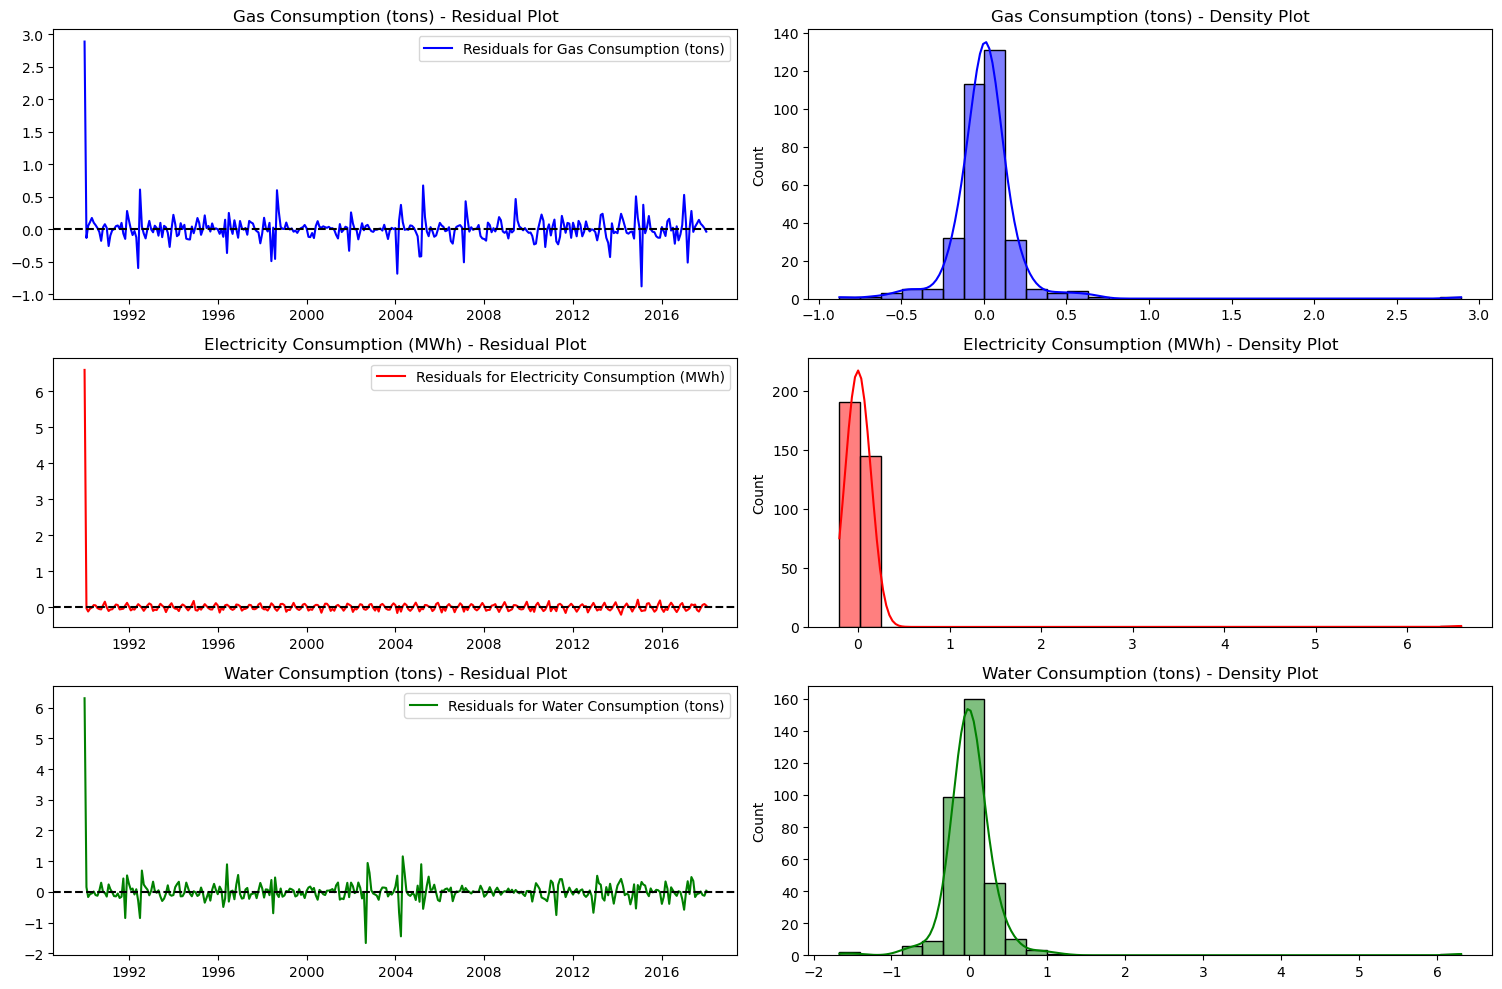

In [115]:
# ------------- Define ARIMA Hyperparameters Manually For Each Variable ------------- #
arima_orders = {
    "Gas Consumption (tons)": (1, 1, 0),
    "Electricity Consumption (MWh)": (1, 1, 0),
    "Water Consumption (tons)": (1, 1, 0)
}

# ------------- Dictionary To Store ARIMA Forecasts And Error Metrics ------------- #
arima_forecasts = {}
arima_mae = {}
arima_rmse = {}
arima_r2 = {}
arima_explained_variance = {}
arima_mape = {}
arima_residuals = {}

# ------------- Training ARIMA And Forecast For Each Variable ------------- #
for column, order in arima_orders.items():
    print(f"Training ARIMA for {column} with order {order}...")

    # Fit ARIMA Model Using Log Transformed Data #
    model = ARIMA(train_log[column], order=order)
    model_fit = model.fit()

    # Forecast For Test Period Using Log Transformed Data #
    forecast_log = model_fit.forecast(steps=len(test_log))
    arima_forecasts[column] = np.exp(forecast_log)

    # Store Residuals #
    arima_residuals[column] = train_log[column] - model_fit.fittedvalues

    # Calculate Error Metrics Using Raw Data #
    mae = mean_absolute_error(test[column], arima_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], arima_forecasts[column]))
    r2 = r2_score(test[column], arima_forecasts[column])
    explained_variance = explained_variance_score(test[column], arima_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], arima_forecasts[column])

    arima_mae[column] = mae
    arima_rmse[column] = rmse
    arima_r2[column] = r2
    arima_explained_variance[column] = explained_variance
    arima_mape[column] = mape

    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
baseline_error_df = pd.DataFrame({
    "Variable": list(arima_mae.keys()),
    "ARIMA Order": list(arima_orders.values()),
    "MAE": list(arima_mae.values()),
    "RMSE": list(arima_rmse.values()),
    "R2 Score": list(arima_r2.values()),
    "Explained Variance Score": list(arima_explained_variance.values()),
    "MAPE": list(arima_mape.values())
})

# ------------- Plotting ARIMA Forecasts ------------- #
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(arima_residuals.keys()):
    # Residual Plot (Now from log-transformed data)
    ax[i, 0].plot(arima_residuals[column], label=f"Residuals for {column}", color=colors[column])
    ax[i, 0].axhline(y=0, color='black', linestyle='dashed')
    ax[i, 0].set_title(f"{column} - Residual Plot")
    ax[i, 0].legend()

    # Density Plot (Now from log-transformed data)
    sns.histplot(arima_residuals[column], bins=30, kde=True, ax=ax[i, 1], color=colors[column])
    ax[i, 1].set_title(f"{column} - Density Plot")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Residual Plot and the Density Plot above, I am able to make the following observations indicated below.</p>
<br/>
<p><strong><u>Residual Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>The residuals are fluctuating around zero, meaning the model has captured much of the trend.</li>
    <li>Some spikes, suggesting occasional model errors.</li>
    <li>Some heteroscedasticity (variance changes over time) may be present.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>The residuals exhibit periodic patterns, indicating the model might not have fully captured seasonality.</li>
    <li>Higher variance towards the end suggests increasing prediction errors.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>Residuals fluctuate around zero, but there are noticeable outliers.</li>
    <li>High variance suggests potential overfitting or missing seasonal components.</li>
</ul>
<br/>
<p><strong><u>Density Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>Bell-shaped but slightly skewed.</li>
    <li>Errors are mostly normally distributed but could have slight bias.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>Bimodal distribution.</li>
    <li>Model may be missing a key pattern, such as a structural change or unaccounted seasonality.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>Heavy tails suggest the presence of outliers.</li>
    <li>Errors are not perfectly normal, which may impact forecasting confidence.</li>
</ul>
<br/>
<p>With the observations indicated, I will proceed to plot out the Time Series.</p>

<hr/>
<h3>6.2.2 Baseline Model Time Series Plot</h3>

<p>In this sub-section, I will be plotting the time series plot where I am able to put the predicted value beside the test data so as to provide an visualisation on the accuracy of the prediction. This Visualisation will be done in the cell below.</p>

Training ARIMA for Gas Consumption (tons) with order (1, 1, 0)...
Finished Gas Consumption (tons): MAE = 2.9543, RMSE = 3.6524, R2 = -0.2300, Explained Variance = -0.0004, MAPE = 0.1228
Training ARIMA for Electricity Consumption (MWh) with order (1, 1, 0)...
Finished Electricity Consumption (MWh): MAE = 197.8273, RMSE = 218.0595, R2 = -4.0045, Explained Variance = -0.0027, MAPE = 0.2020
Training ARIMA for Water Consumption (tons) with order (1, 1, 0)...
Finished Water Consumption (tons): MAE = 100.9471, RMSE = 121.4370, R2 = -0.4134, Explained Variance = -0.0008, MAPE = 0.2052


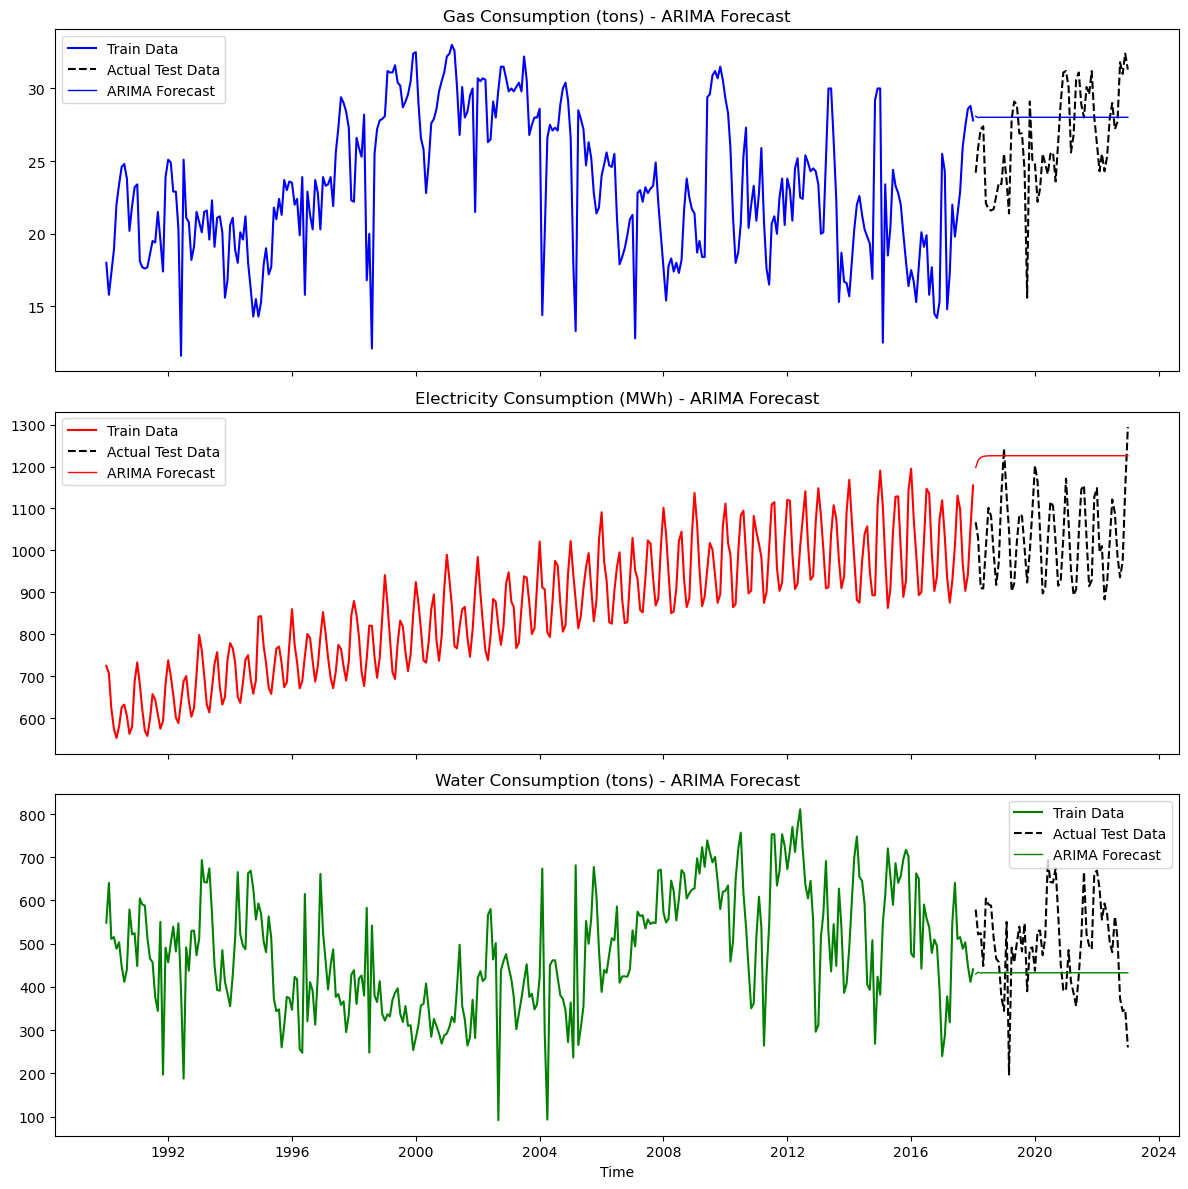

In [119]:
# ------------- Defining ARIMA Hyperparameters ------------- #
arima_orders = {
    "Gas Consumption (tons)": (1, 1, 0),
    "Electricity Consumption (MWh)": (1, 1, 0),
    "Water Consumption (tons)": (1, 1, 0)
}

# ------------- Dictionary To Store ARIMA Forecasts And Error Metrics ------------- #
arima_forecasts = {}
arima_mae = {}
arima_rmse = {}
arima_r2 = {}
arima_explained_variance = {}
arima_mape = {}

# ------------- Training ARIMA And Forecast For Each Variable ------------- #
for column, order in arima_orders.items():
    print(f"Training ARIMA for {column} with order {order}...")
    
    # Fit ARIMA model #
    model = ARIMA(train_log[column], order=order)
    model_fit = model.fit()
    
    # Forecast For Test Period #
    forecast = model_fit.forecast(steps=len(test_log))
    arima_forecasts[column] = np.exp(forecast)
    
    # Calculate Error Metrics #
    mae = mean_absolute_error(test[column], arima_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], arima_forecasts[column]))
    r2 = r2_score(test[column], arima_forecasts[column])
    explained_variance = explained_variance_score(test[column], arima_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], arima_forecasts[column])
    
    arima_mae[column] = mae
    arima_rmse[column] = rmse
    arima_r2[column] = r2
    arima_explained_variance[column] = explained_variance
    arima_mape[column] = mape
    
    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
baseline_error_df = pd.DataFrame({
    "Variable": list(arima_mae.keys()),
    "ARIMA Order": list(arima_orders.values()),
    "MAE": list(arima_mae.values()),
    "RMSE": list(arima_rmse.values()),
    "R2 Score": list(arima_r2.values()),
    "Explained Variance Score": list(arima_explained_variance.values()),
    "MAPE": list(arima_mape.values())
})

# ------------- Plotting ARIMA Forecasts ------------- #
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(arima_orders.keys()):
    axes[i].plot(train.index, train[column], label="Train Data", color=colors[column])
    axes[i].plot(test.index, test[column], label="Actual Test Data", color='black', linestyle='dashed')
    axes[i].plot(test.index, arima_forecasts[column], label="ARIMA Forecast", color=colors[column], linestyle='solid', linewidth=1)
    axes[i].set_title(f"{column} - ARIMA Forecast")
    axes[i].legend()

# ------------- Displaying Plot ------------- #
plt.xlabel("Time")
plt.tight_layout()
plt.show()

<p>WIth reference to the output of the Time Series plto above, I am able to see that generally, the Forecast for all the Consumptions are a straight line. This is most likely due to the model being a Baseline model and there is not strong input of parameters which allows it to adjsut according to past patterns.</p>

<hr/>
<h3>6.2.3 Baseline Model Performance Metrics</h3>

<p>In this sub-section, I will be showing the performance metrics for the Baseline Model as previously saved in a DataFrame. I will be evaluting the various metrics such as R2, MAE, RMSE, Explained Variance Score and MAPE. This operation will be conducted in the cell below.</p>

In [123]:
# ------------- Displaying DataFrame ------------- #
baseline_error_df.style.background_gradient(cmap="Blues")

,Variable,ARIMA Order,MAE,RMSE,R2 Score,Explained Variance Score,MAPE
0,Gas Consumption (tons),"(1, 1, 0)",2.954328,3.652395,-0.229976,-0.000398,0.122795
1,Electricity Consumption (MWh),"(1, 1, 0)",197.827313,218.059507,-4.004529,-0.002740,0.201997
2,Water Consumption (tons),"(1, 1, 0)",100.947112,121.437014,-0.413446,-0.000753,0.205248


<p>With reference to the output above, I am able to see that generally, the Baseline model performance was relatively poor with the R2 Score being in the negatives. However, this is acceptable as this serves as a Basis of Comparison to the other models and will not be used to predict any values.</p>

<hr/>
<h2>6.3 ARIMA (Autoregressive Integrated Moving Average) Model</h2>

<p>In this section, I will be training the ARIMA model to attempt to predict the test values and also to try to tune it such that it is the best model for predicting the next 60 months of Consumptions. Subsequently, I will be evaluating and visualising the performance of the Model. The formula for the ARIMA model is indicated below.</p>

$$
\Phi_p(B) (1 - B)^d Y_t = \Theta_q(B) \epsilon_t
$$

**where:**

- $ B $ is the **backshift operator**, where $ B Y_t = Y_{t-1} $.
- The **Auto-Regressive (AR) component** is:

  $$
  \Phi_p(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p
  $$

- The **Moving Average (MA) component** is:

  $$
  \Theta_q(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q
  $$

- $ d $ is the **order of differencing**.
- $ \epsilon_t $ is **white noise**.

<br/>
<p>With the formula for ARIMA indicated, I will proceed to train the model.</p>

<hr/>
<h3>6.3.1 ARIMA Best Parameter</h3>

<p>I will be utilisng a GridSearch to find the Best and Most Accurate Parameter for the ARIMA Time Series Model. The best parameter is determined by the highest R2. It will iterate through various p, d and q values so as to find the best parameter.</p>

In [129]:
# ---------- Defining Parameter Grid ---------- #
p_values = range(8, 20)
d_values = range(1, 2)
q_values = range(8, 20)

# ---------- Dictionary To Store Best Results ---------- #
best_arima_models = {
    'Variable': [],
    'Best ARIMA Order': [],
    'R2 Score': [],
    'Explained Variance': [],
    'MSE': [],
    'MAE': [],
    'MAPE': []
}

# ---------- Looping Through Each Variable ---------- #
for column in ["Gas Consumption (tons)", "Electricity Consumption (MWh)", "Water Consumption (tons)"]:
    best_r2 = -float("inf")  # Track best R2
    best_order = None
    best_metrics = {}

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            # Fit ARIMA Model On Log Transformed Data #
            model = ARIMA(np.log(train[column]), order=(p, d, q))
            result = model.fit()

            # Forecast Using Predict To Match Final Training #
            predictions_log = result.predict(start=len(train), end=len(train)+len(test)-1)
            predictions = np.exp(predictions_log)

            # Compute Metrics #
            r2 = r2_score(test[column], predictions)
            mse = mean_squared_error(test[column], predictions)
            mae = mean_absolute_error(test[column], predictions)
            mape = mean_absolute_percentage_error(test[column], predictions)
            evs = explained_variance_score(test[column], predictions)

            # Store Best Performing Model #
            if r2 > best_r2:
                best_r2 = r2
                best_order = (p, d, q)
                best_metrics = {"R2": r2, "MSE": mse, "MAE": mae, "MAPE": mape, "Explained Variance": evs}
        
        except:
            continue

    # Save Best Results For This Variable #
    best_arima_models['Variable'].append(column)
    best_arima_models['Best ARIMA Order'].append(best_order)
    best_arima_models['R2 Score'].append(best_metrics["R2"])
    best_arima_models['Explained Variance'].append(best_metrics["Explained Variance"])
    best_arima_models['MSE'].append(best_metrics["MSE"])
    best_arima_models['MAE'].append(best_metrics["MAE"])
    best_arima_models['MAPE'].append(best_metrics["MAPE"])

# ---------- Converting To DataFrame ---------- #
arima_result_df = pd.DataFrame(best_arima_models)

# ---------- Displaying DataFrame ---------- #
arima_result_df.style.background_gradient(cmap="Blues")

,Variable,Best ARIMA Order,R2 Score,Explained Variance,MSE,MAE,MAPE
0,Gas Consumption (tons),"(18, 1, 9)",-1.110402,-0.199329,22.888862,3.998905,0.145554
1,Electricity Consumption (MWh),"(8, 1, 8)",0.776596,0.779166,2122.643862,36.697694,0.034733
2,Water Consumption (tons),"(9, 1, 17)",0.014433,0.015053,10282.749063,77.724024,0.179988


<p>With reference to the output of the DataFrame above, I am able to see the various best order for each of the variable. I will be using these orders and putting it in the Model Training and subsequently, evaluating the performance of the ARIMA Model.</p>

<hr/>
<h3>6.3.2 ARIMA Model Training</h3>

<p>I will be training the ARIMA Model based on the training data. Subsequently, I will adjust the ARIMA Order accordingly should there be a need. This motion will be repeated until the ideal model parameter is obtained.</p>

Training ARIMA for Gas Consumption (tons) with order (18, 2, 9)...
Finished Gas Consumption (tons): MAE = 2.6885, RMSE = 3.3074, R2 = -0.0086, Explained Variance = 0.1051, MAPE = 0.1017
Training ARIMA for Electricity Consumption (MWh) with order (8, 1, 8)...
Finished Electricity Consumption (MWh): MAE = 36.6977, RMSE = 46.0722, R2 = 0.7766, Explained Variance = 0.7792, MAPE = 0.0347
Training ARIMA for Water Consumption (tons) with order (9, 1, 17)...
Finished Water Consumption (tons): MAE = 77.7240, RMSE = 101.4039, R2 = 0.0144, Explained Variance = 0.0151, MAPE = 0.1800


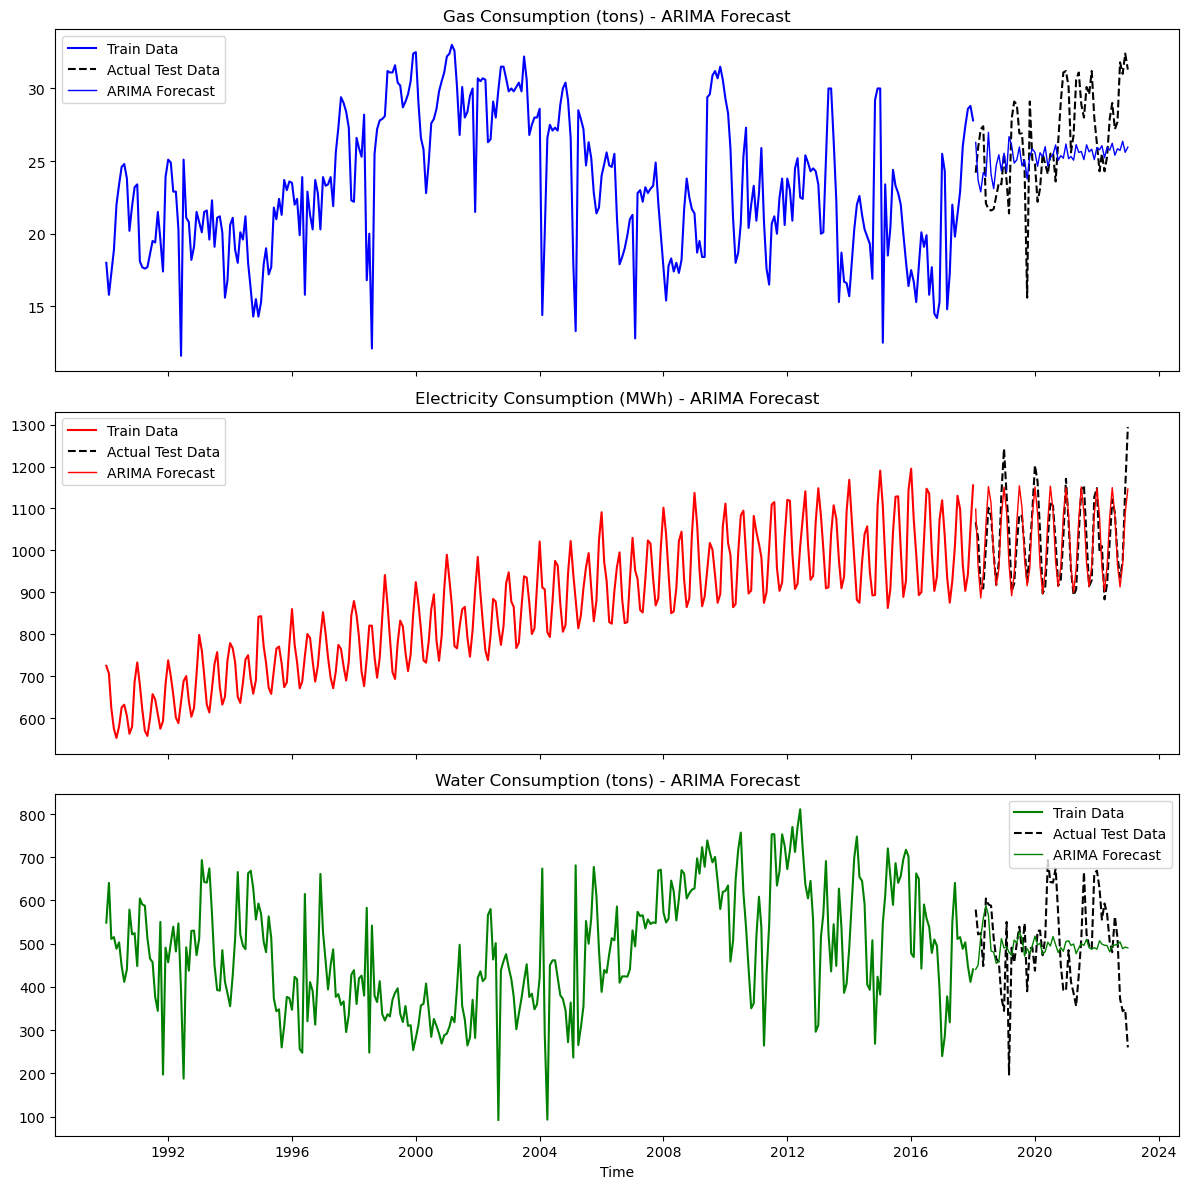

In [133]:
# ------------- Defining ARIMA Hyperparameters ------------- #
arima_orders = {
    "Gas Consumption (tons)": (18, 2, 9),
    "Electricity Consumption (MWh)": (8, 1, 8),
    "Water Consumption (tons)": (9, 1, 17)
}

# ------------- Dictionary To Store ARIMA Forecasts And Error Metrics ------------- #
arima_forecasts = {}
arima_mae = {}
arima_rmse = {}
arima_r2 = {}
arima_explained_variance = {}
arima_mape = {}

# ------------- Training ARIMA And Forecast For Each Variable ------------- #
for column, order in arima_orders.items():
    print(f"Training ARIMA for {column} with order {order}...")
    
    # Fit ARIMA model #
    model = ARIMA(train_log[column], order=order)
    model_fit = model.fit()
    
    # Forecast For Test Period #
    forecast = model_fit.forecast(steps=len(test_log))
    arima_forecasts[column] = np.exp(forecast)
    
    # Calculate Error Metrics #
    mae = mean_absolute_error(test[column], arima_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], arima_forecasts[column]))
    r2 = r2_score(test[column], arima_forecasts[column])
    explained_variance = explained_variance_score(test[column], arima_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], arima_forecasts[column])
    
    arima_mae[column] = mae
    arima_rmse[column] = rmse
    arima_r2[column] = r2
    arima_explained_variance[column] = explained_variance
    arima_mape[column] = mape
    
    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
arima_error_df = pd.DataFrame({
    "Variable": list(arima_mae.keys()),
    "ARIMA Order": list(arima_orders.values()),
    "MAE": list(arima_mae.values()),
    "RMSE": list(arima_rmse.values()),
    "R2 Score": list(arima_r2.values()),
    "Explained Variance Score": list(arima_explained_variance.values()),
    "MAPE": list(arima_mape.values())
})

# ------------- Plotting ARIMA Forecasts ------------- #
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(arima_orders.keys()):
    axes[i].plot(train.index, train[column], label="Train Data", color=colors[column])
    axes[i].plot(test.index, test[column], label="Actual Test Data", color='black', linestyle='dashed')
    axes[i].plot(test.index, arima_forecasts[column], label="ARIMA Forecast", color=colors[column], linestyle='solid', linewidth=1)
    axes[i].set_title(f"{column} - ARIMA Forecast")
    axes[i].legend()

# ------------- Displaying Plot ------------- #
plt.xlabel("Time")
plt.tight_layout()
plt.show()

<p>With reference to the output of the Time Series Plot, I am able to see that generally ARIMA perfromed well for predicting Electricity Consumption. However, the ARIMA Model did not perform as well for Gas Consumption and Water Consumption as the Forecast is generally extremely linear for these consumptions. I will proceed to use the Residual Plot and Density Plot to evalaute the model's performance.</p>

<hr/>
<h3>6.3.3 ARIMA Model Evaluation</h3>

<p>To evaluate the performance of the ARIMA Model, I will be utilising a Residual Plot and a Density Plot. The Residual Plot is able to help us assess the Model's accuracy by analysing the difference between actual and predicted values and also check for residual error and ensure they are randomly distributed. The density plot is able to show us the distribution of errors and also to check for biasness.</p>

Training ARIMA for Gas Consumption (tons) with order (18, 2, 9)...
Finished Gas Consumption (tons): MAE = 2.6885, RMSE = 3.3074, R2 = -0.0086, Explained Variance = 0.1051, MAPE = 0.1017
Training ARIMA for Electricity Consumption (MWh) with order (8, 1, 8)...
Finished Electricity Consumption (MWh): MAE = 36.6977, RMSE = 46.0722, R2 = 0.7766, Explained Variance = 0.7792, MAPE = 0.0347
Training ARIMA for Water Consumption (tons) with order (9, 1, 17)...
Finished Water Consumption (tons): MAE = 77.7240, RMSE = 101.4039, R2 = 0.0144, Explained Variance = 0.0151, MAPE = 0.1800


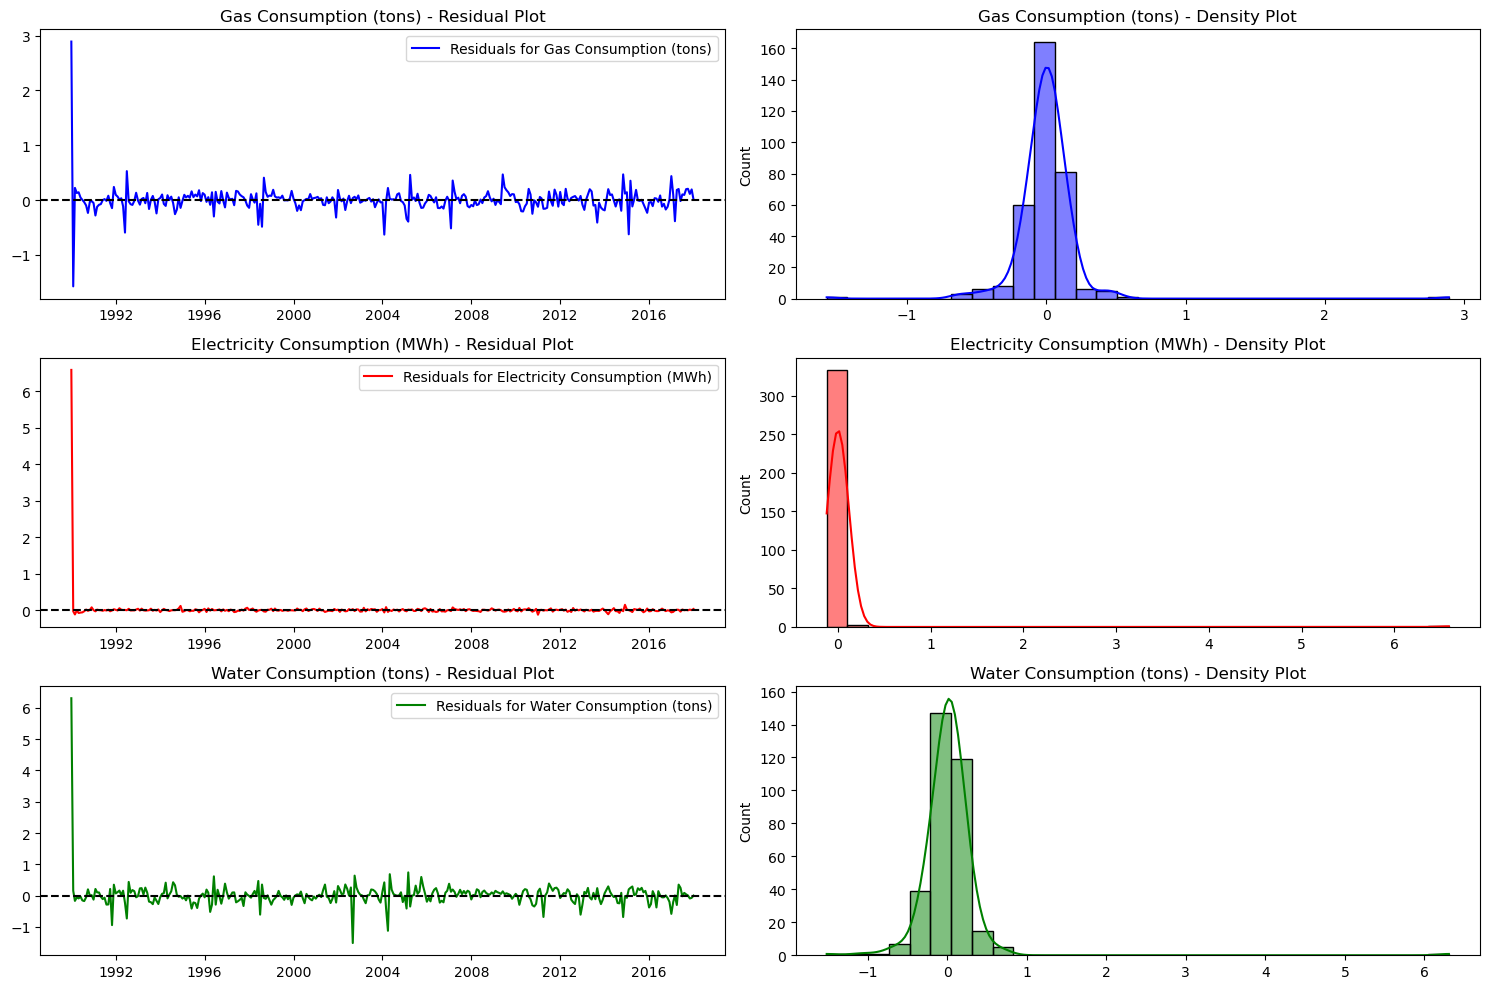

In [137]:
# ------------- Define ARIMA Hyperparameters Manually For Each Variable ------------- #
arima_orders = {
    "Gas Consumption (tons)": (18, 2, 9),
    "Electricity Consumption (MWh)": (8, 1, 8),
    "Water Consumption (tons)": (9, 1, 17)
}

# ------------- Dictionary To Store ARIMA Forecasts And Error Metrics ------------- #
arima_forecasts = {}
arima_mae = {}
arima_rmse = {}
arima_r2 = {}
arima_explained_variance = {}
arima_mape = {}
arima_residuals = {}

# ------------- Training ARIMA And Forecast For Each Variable ------------- #
for column, order in arima_orders.items():
    print(f"Training ARIMA for {column} with order {order}...")

    # Fit ARIMA Model Using Log Transformed Data #
    model = ARIMA(train_log[column], order=order)
    model_fit = model.fit()

    # Forecast For Test Period Using Log Transformed Data #
    forecast_log = model_fit.forecast(steps=len(test_log))
    arima_forecasts[column] = np.exp(forecast_log)

    # Store Residuals #
    arima_residuals[column] = train_log[column] - model_fit.fittedvalues

    # Calculate Error Metrics Using Raw Data #
    mae = mean_absolute_error(test[column], arima_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], arima_forecasts[column]))
    r2 = r2_score(test[column], arima_forecasts[column])
    explained_variance = explained_variance_score(test[column], arima_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], arima_forecasts[column])

    arima_mae[column] = mae
    arima_rmse[column] = rmse
    arima_r2[column] = r2
    arima_explained_variance[column] = explained_variance
    arima_mape[column] = mape

    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
arima_error_df = pd.DataFrame({
    "Variable": list(arima_mae.keys()),
    "ARIMA Order": list(arima_orders.values()),
    "MAE": list(arima_mae.values()),
    "RMSE": list(arima_rmse.values()),
    "R2 Score": list(arima_r2.values()),
    "Explained Variance Score": list(arima_explained_variance.values()),
    "MAPE": list(arima_mape.values())
})

# ------------- Plotting ARIMA Forecasts ------------- #
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(arima_residuals.keys()):
    # Residual Plot (Now from log-transformed data)
    ax[i, 0].plot(arima_residuals[column], label=f"Residuals for {column}", color=colors[column])
    ax[i, 0].axhline(y=0, color='black', linestyle='dashed')
    ax[i, 0].set_title(f"{column} - Residual Plot")
    ax[i, 0].legend()

    # Density Plot (Now from log-transformed data)
    sns.histplot(arima_residuals[column], bins=30, kde=True, ax=ax[i, 1], color=colors[column])
    ax[i, 1].set_title(f"{column} - Density Plot")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Residual Plot and the Density Plot above, I am able to make the following observations indicated below.</p>
<br/>
<p><strong><u>Residual Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>The residuals are mostly centered around zero, indicating a reasonable fit.</li>
    <li>There is some variation, but it remains consistent over time.</li>
    <li>No obvious trend or pattern in residuals suggests that the model captures the data well.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>A huge spike at the start suggests an anomaly or sudden change in the data.</li>
    <li>After the initial spike, the residuals are very close to zero.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>The residuals fluctuate around zero, but show slightly more spread than gas and electricity.</li>
    <li>There is an initial spike, similar to electricity, but it stabilizes over time.</li>
    <li>Residuals appear more randomly distributed, indicating a better fit.</li>
</ul>
<br/>
<p><strong><u>Density Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>The residuals appear to be normally distributed with a slight skew.</li>
    <li>The peak is centered around zero, indicating minimal bias.</li>
    <li>The tails suggest the presence of some outliers, meaning the model may struggle with extreme values.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>The distribution is highly skewed to the right, indicating the presence of many small residuals and a few large ones.</li>
    <li>The peak at zero confirms that most residuals are near zero.</li>
    <li>The long tail suggests the model occasionally makes large errors.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>The distribution is almost normal, but with some skew.</li>
    <li>The peak around zero suggests low bias, but there are still some outliers.</li>
    <li>The residuals are more spread out.</li>
</ul>
<br/>
<p>With the observations indicated, I will proceed to Evaluate the performance of the ARIMA Model.</p>

<hr/>
<h3>6.3.4 ARIMA Model Performance Metrics</h3>

<p>In this sub-section, I will be showing the performance metrics for the ARIMA Model as previously saved in a DataFrame. I will be evaluting the various metrics such as R2, MAE, RMSE, Explained Variance Score and MAPE. This operation will be conducted in the cell below.</p>

In [141]:
# ------------- Displaying DataFrame ------------- #
arima_error_df.style.background_gradient(cmap="Blues")

,Variable,ARIMA Order,MAE,RMSE,R2 Score,Explained Variance Score,MAPE
0,Gas Consumption (tons),"(18, 2, 9)",2.688515,3.307355,-0.008562,0.105145,0.101671
1,Electricity Consumption (MWh),"(8, 1, 8)",36.697694,46.072159,0.776596,0.779166,0.034733
2,Water Consumption (tons),"(9, 1, 17)",77.724024,101.403891,0.014433,0.015053,0.179988


<p>With reference to the output of the DataFrame above, I am able to see that generally, the Electricity Consumption performed extremely well whereas the Gas and Water consumption performed badly. However, all three Features Prediction outperformed the Baseline Model. Therefore, this model will be used a comparison to SARIMAX to determine if it is the best model to be deployed.</p>

<hr/>
<h2>6.4 SARIMAX (Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors) Model</h2>

<p>In this section, I will be training the SARIMAX model to attempt to predict the test values and also to try to tune it such that it is the best model for predicting the next 60 months of Consumptions. Subsequently, I will be evaluating and visualising the performance of the Model. The formula for the SARIMAX model is indicated below.</p>

$$
\Phi_p(B) (1 - B)^d Y_t = \Theta_q(B) \epsilon_t + X_t \beta + S_P(B_s)
$$

**where:**
- $ B $ is the **backshift operator**, where $ B Y_t = Y_{t-1} $.
- The **Auto-Regressive (AR) component** is:
  $$
  \Phi_p(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p
  $$
- The **Moving Average (MA) component** is:
  $$
  \Theta_q(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q
  $$
- The **Seasonal Component** is:
  $$
  S_P(B_s) = 1 - \Phi_1 B^s - \Phi_2 B^{2s} - \dots - \Phi_P B^{Ps}
  $$

**where:**
- $ B^s $ is the **seasonal backshift operator**.
- $ d $ is the **order of differencing**.
- $ \epsilon_t $ is **white noise**.
- $ X_t \beta $ represents **exogenous variables** in SARIMAX.

<br/>
<p>With the formula for ARIMA indicated, I will proceed to train the model.</p>

<hr/>
<h3>6.4.1 SARIMAX Model Training</h3>

<p>I will be training the SARIMAX Model based on the training data. Subsequently, I will adjust the SARIMAX Order accordingly should there be a need. This motion will be repeated until the ideal model parameter is obtained.</p>

Training SARIMAX for Gas Consumption (tons) with order (5, 0, 3) and seasonal order (9, 1, 6, 12)...
Finished Gas Consumption (tons): MAE = 3.9049, RMSE = 4.6743, R2 = -1.0145, Explained Variance = 0.0181, MAPE = 0.1423
Training SARIMAX for Electricity Consumption (MWh) with order (3, 1, 4) and seasonal order (5, 1, 6, 12)...
Finished Electricity Consumption (MWh): MAE = 28.4791, RMSE = 39.0649, R2 = 0.8394, Explained Variance = 0.8559, MAPE = 0.0265
Training SARIMAX for Water Consumption (tons) with order (2, 0, 1) and seasonal order (9, 1, 6, 12)...
Finished Water Consumption (tons): MAE = 79.1743, RMSE = 103.4536, R2 = -0.0258, Explained Variance = 0.0551, MAPE = 0.1714


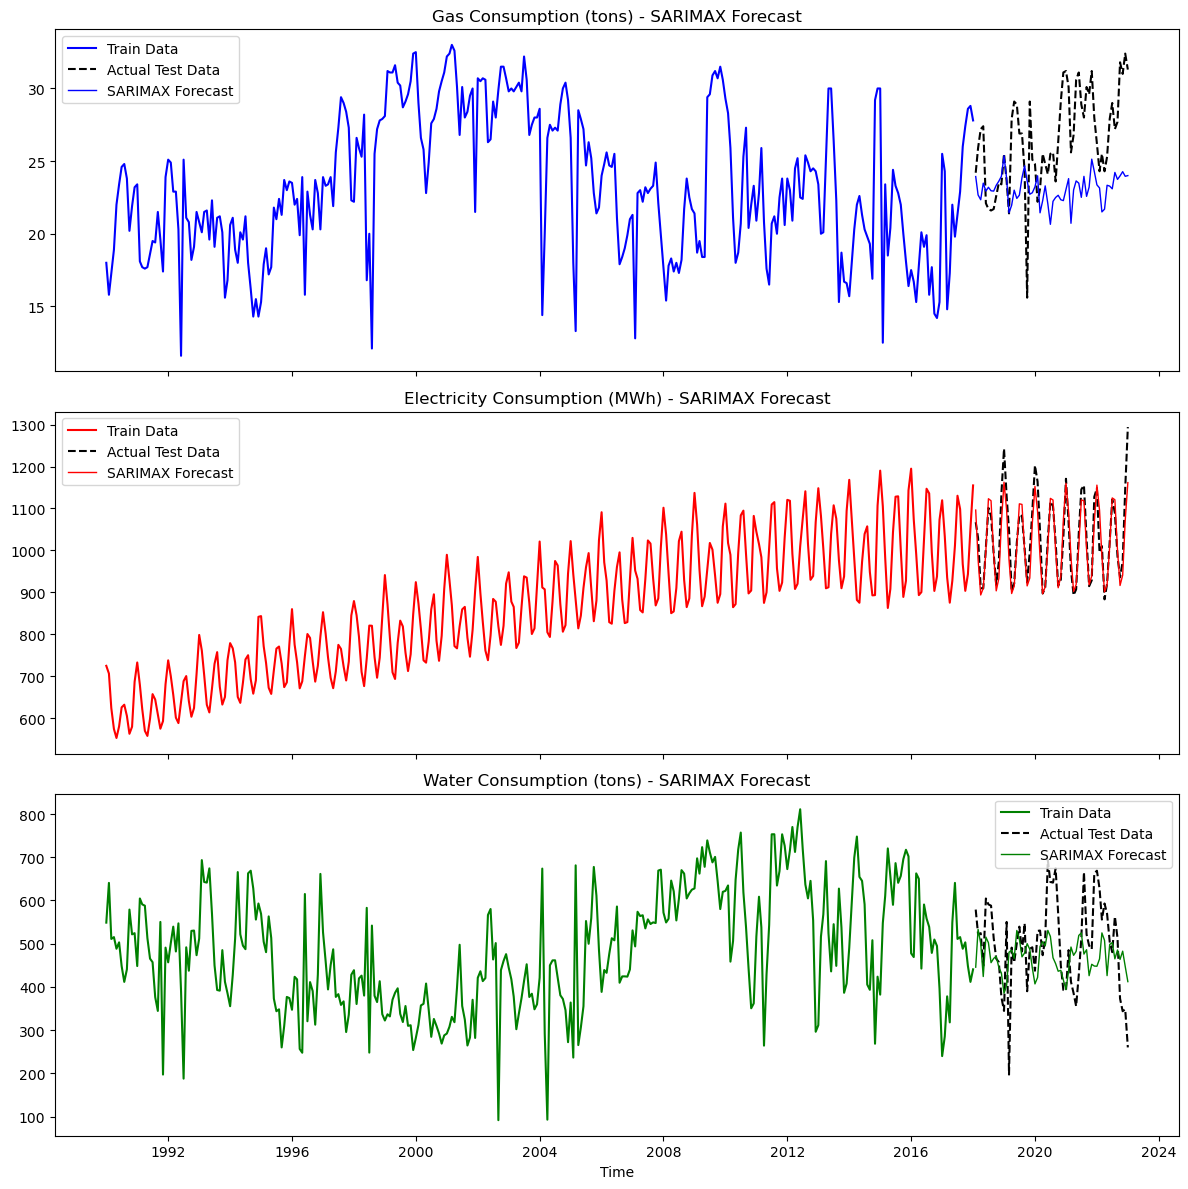

In [147]:
# ------------- Define SARIMAX Hyperparameters Manually For Each Variable ------------- #
sarimax_orders = {
    "Gas Consumption (tons)": ((5, 0, 3), (9, 1, 6, 12)),
    "Electricity Consumption (MWh)": ((3, 1, 4), (5, 1, 6, 12)),
    "Water Consumption (tons)": ((2, 0, 1), (9, 1, 6, 12))
}

# ------------- Dictionary To Store ARIMA Forecasts And Error Metrics ------------- #
sarimax_forecasts = {}
sarimax_mae = {}
sarimax_rmse = {}
sarimax_r2 = {}
sarimax_explained_variance = {}
sarimax_mape = {}

# ------------- Training ARIMA And Forecast For Each Variable ------------- #
for column, (order, seasonal_order) in sarimax_orders.items():
    print(f"Training SARIMAX for {column} with order {order} and seasonal order {seasonal_order}...")
    
    # Fitting SARIMAX Model #
    model = SARIMAX(train_log[column], order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    
    # Forecast For Test Period #
    forecast = model_fit.forecast(steps=len(test_log))
    sarimax_forecasts[column] = np.exp(forecast)
    
    # Calculate Error Metrics #
    mae = mean_absolute_error(test[column], sarimax_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], sarimax_forecasts[column]))
    r2 = r2_score(test[column], sarimax_forecasts[column])
    explained_variance = explained_variance_score(test[column], sarimax_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], sarimax_forecasts[column])
    
    sarimax_mae[column] = mae
    sarimax_rmse[column] = rmse
    sarimax_r2[column] = r2
    sarimax_explained_variance[column] = explained_variance
    sarimax_mape[column] = mape
    
    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
sarimax_error_df = pd.DataFrame({
    "Variable": list(sarimax_mae.keys()),
    "SARIMAX Order": list(sarimax_orders.values()),
    "MAE": list(sarimax_mae.values()),
    "RMSE": list(sarimax_rmse.values()),
    "R2 Score": list(sarimax_r2.values()),
    "Explained Variance Score": list(sarimax_explained_variance.values()),
    "MAPE": list(sarimax_mape.values())
})

# ------------- Plotting SARIMAX Forecasts ------------- #
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(sarimax_orders.keys()):
    axes[i].plot(train.index, train[column], label="Train Data", color=colors[column])
    axes[i].plot(test.index, test[column], label="Actual Test Data", color='black', linestyle='dashed')
    axes[i].plot(test.index, sarimax_forecasts[column], label="SARIMAX Forecast", color=colors[column], linestyle='solid', linewidth=1)
    axes[i].set_title(f"{column} - SARIMAX Forecast")
    axes[i].legend()

# ------------- Displaying Plot ------------- #
plt.xlabel("Time")
plt.tight_layout()
plt.show()

<p>With reference to the output of the Time Series Plot, I am able to see that generally SARIMAX perfromed well for predicting Electricity Consumption. However, the SARIMAX Model did not perform as well for Gas Consumption and Water Consumption as the Forecast is generally falling short of the Actual Test Data.</p>

<hr/>
<h3>6.4.2 SARIMAX Model Evaluation</h3>

<p>To evaluate the performance of the SARIMAX Model, I will be utilising a Residual Plot and a Density Plot. The Residual Plot is able to help us assess the Model's accuracy by analysing the difference between actual and predicted values and also check for residual error and ensure they are randomly distributed. The density plot is able to show us the distribution of errors and also to check for biasness.</p>

Training SARIMAX for Gas Consumption (tons) with order (5, 0, 3) and seasonal order (9, 1, 6, 12)...
Finished Gas Consumption (tons): MAE = 3.9049, RMSE = 4.6743, R2 = -1.0145, Explained Variance = 0.0181, MAPE = 0.1423
Training SARIMAX for Electricity Consumption (MWh) with order (3, 1, 4) and seasonal order (5, 1, 6, 12)...
Finished Electricity Consumption (MWh): MAE = 28.4791, RMSE = 39.0649, R2 = 0.8394, Explained Variance = 0.8559, MAPE = 0.0265
Training SARIMAX for Water Consumption (tons) with order (2, 0, 1) and seasonal order (9, 1, 6, 12)...
Finished Water Consumption (tons): MAE = 79.1743, RMSE = 103.4536, R2 = -0.0258, Explained Variance = 0.0551, MAPE = 0.1714


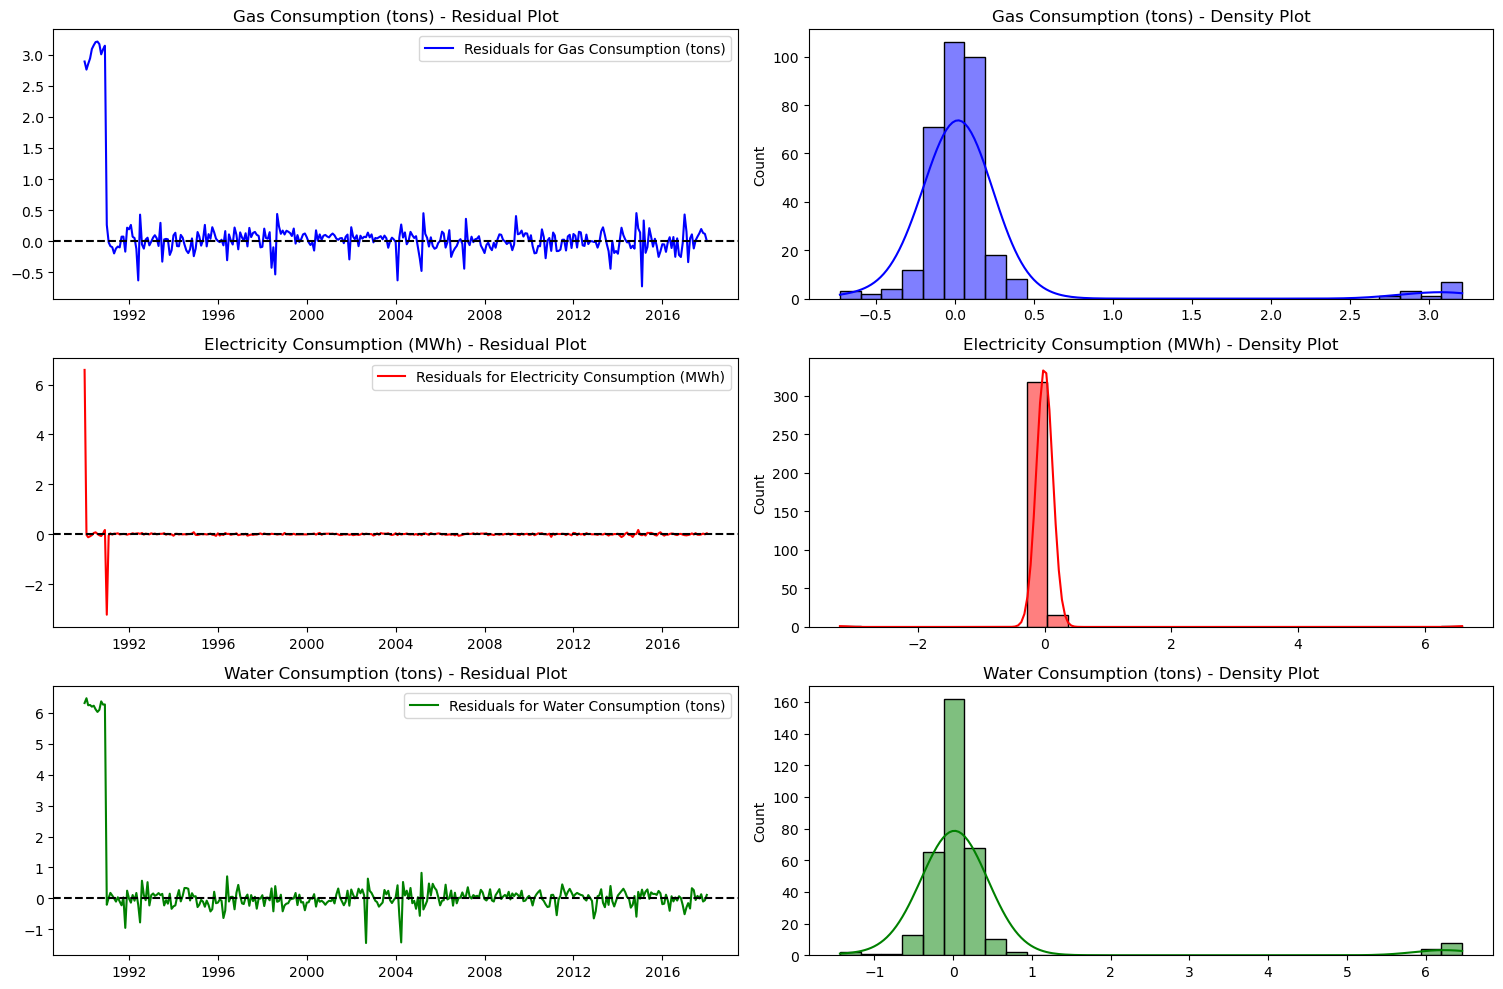

In [151]:
# ------------- Define SARIMAX Hyperparameters Manually For Each Variable ------------- #
sarimax_orders = {
    "Gas Consumption (tons)": ((5, 0, 3), (9, 1, 6, 12)),
    "Electricity Consumption (MWh)": ((3, 1, 4), (5, 1, 6, 12)),
    "Water Consumption (tons)": ((2, 0, 1), (9, 1, 6, 12))
}

# ------------- Dictionary To Store SARIMAX Forecasts And Error Metrics ------------- #
sarimax_forecasts = {}
sarimax_mae = {}
sarimax_rmse = {}
sarimax_r2 = {}
sarimax_explained_variance = {}
sarimax_mape = {}
sarimax_residuals = {}

# ------------- Training SARIMAX And Forecast For Each Variable ------------- #
for column, (order, seasonal_order) in sarimax_orders.items():
    print(f"Training SARIMAX for {column} with order {order} and seasonal order {seasonal_order}...")

    # Fit SARIMAX Model Using Log Transformed Data #
    model = SARIMAX(train_log[column], order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()

    # Forecast For Test Period Using Log Transformed Data #
    forecast_log = model_fit.forecast(steps=len(test_log))
    sarimax_forecasts[column] = np.exp(forecast_log)

    # Store Residuals #
    sarimax_residuals[column] = train_log[column] - model_fit.fittedvalues

    # Calculate Error Metrics Using Raw Data #
    mae = mean_absolute_error(test[column], sarimax_forecasts[column])
    rmse = np.sqrt(mean_squared_error(test[column], sarimax_forecasts[column]))
    r2 = r2_score(test[column], sarimax_forecasts[column])
    explained_variance = explained_variance_score(test[column], sarimax_forecasts[column])
    mape = mean_absolute_percentage_error(test[column], sarimax_forecasts[column])

    sarimax_mae[column] = mae
    sarimax_rmse[column] = rmse
    sarimax_r2[column] = r2
    sarimax_explained_variance[column] = explained_variance
    sarimax_mape[column] = mape

    print(f"Finished {column}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}, Explained Variance = {explained_variance:.4f}, MAPE = {mape:.4f}")

# ------------- Storing Error Metrics In DataFrame ------------- #
sarimax_error_df = pd.DataFrame({
    "Variable": list(sarimax_mae.keys()),
    "SARIMAX Order": list(sarimax_orders.values()),
    "MAE": list(sarimax_mae.values()),
    "RMSE": list(sarimax_rmse.values()),
    "R2 Score": list(sarimax_r2.values()),
    "Explained Variance Score": list(sarimax_explained_variance.values()),
    "MAPE": list(sarimax_mape.values())
})

# ------------- Plotting SARIMAX Forecasts ------------- #
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

colors = {"Gas Consumption (tons)": "blue", "Electricity Consumption (MWh)": "red", "Water Consumption (tons)": "green"}

for i, column in enumerate(sarimax_residuals.keys()):
    # Residual Plot #
    ax[i, 0].plot(sarimax_residuals[column], label=f"Residuals for {column}", color=colors[column])
    ax[i, 0].axhline(y=0, color='black', linestyle='dashed')
    ax[i, 0].set_title(f"{column} - Residual Plot")
    ax[i, 0].legend()

    # Density Plot #
    sns.histplot(sarimax_residuals[column], bins=30, kde=True, ax=ax[i, 1], color=colors[column])
    ax[i, 1].set_title(f"{column} - Density Plot")

# ------------- Displaying Plot ------------- #
plt.tight_layout()
plt.show()

<p>With reference to the output of the Residual Plot and the Density Plot above, I am able to make the following observations indicated below.</p>
<br/>
<p><strong><u>Residual Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>There is a large initial spike, indicating a possible anomaly or instability at the start.</li>
    <li>After the spike, residuals seem randomly distributed around zero, which is a good sign.</li>
    <li>The variance appears fairly stable over time, meaning the model captures the trend well.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>A major spike at the start, similar to gas consumption, indicating possible early model instability.</li>
    <li>After the spike, residuals are almost flat, meaning the model is capturing the data very well.</li>
    <li>Very low variance, suggesting minimal forecasting errors.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>Another initial spike, likely due to data fluctuations at the beginning of the time series.</li>
    <li>Residuals appear evenly distributed around zero after the first few years.</li>
    <li>There is some visible variance in later years, suggesting the model might struggle slightly with capturing changes.</li>
</ul>
<br/>
<p><strong><u>Density Plot</u></strong></p>
<ul>
    <p><strong><u>Gas Consumption</u></strong></p>
    <li>The distribution is slightly right-skewed, meaning some higher residual values exist.</li>
    <li>There are outliers on the right (above 3.0), which could suggest occasional over-predictions.</li>
    <li>The main residual values are centered near 0, indicating that the model is generally well-calibrated.</li>
    <br/>
    <p><strong><u>Electricity Consumption</u></strong></p>
    <li>The residuals are extremely concentrated around zero, meaning the model's predictions are very close to actual values.</li>
    <li>Very narrow and tall peak, which suggests low variance and high model accuracy.</li>
    <li>Almost no extreme values, meaning there are no significant over- or under-predictions.</li>
    <br/>
    <p><strong><u>Water Consumption</u></strong></p>
    <li>The distribution is almost normal, but with some skew.</li>
    <li>The main residuals are mostly centered around zero, indicating good model performance.</li>
</ul>
<br/>
<p>With the observations indicated, I will proceed to Evaluate the performance of the SARIMAX Model.</p>

<hr/>
<h3>6.4.3 SARIMAX Model Performance Metrics</h3>

<p>In this sub-section, I will be showing the performance metrics for the SARIMAX Model as previously saved in a DataFrame. I will be evaluting the various metrics such as R2, MAE, RMSE, Explained Variance Score and MAPE. This operation will be conducted in the cell below.</p>

In [155]:
sarimax_error_df.style.background_gradient(cmap="Blues")

,Variable,SARIMAX Order,MAE,RMSE,R2 Score,Explained Variance Score,MAPE
0,Gas Consumption (tons),"((5, 0, 3), (9, 1, 6, 12))",3.904889,4.674279,-1.014514,0.018138,0.142284
1,Electricity Consumption (MWh),"((3, 1, 4), (5, 1, 6, 12))",28.479077,39.064938,0.839385,0.855936,0.026516
2,Water Consumption (tons),"((2, 0, 1), (9, 1, 6, 12))",79.174317,103.453577,-0.025812,0.055082,0.171447


<p>With reference to the output of the DataFrame above, I am able to see that generally, the Electricity Consumption performed extremely well whereas the Gas and Water consumption performed badly. However, all three Features Prediction outperformed the Baseline Model. Therefore, this model will be used a comparison to SARIMAX to determine if it is the best model to be deployed.</p>